# AT3 — Explicabilidade local: regressão de chuva forte

A árvore de regressão salva pelo `atv3_extremos` (quanto chove, dado que o dia é forte), explicada em quatro dias do teste com CP, ICE, LIME, SHAP e, como método adicional, contrafactuais com DiCE. A classificação é explicada à parte, nos mesmos quatro dias.

In [1]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook", palette="deep", font_scale=1.4)
pd.set_option("display.width", 140)

In [2]:
# No Colab, descomente para montar o Drive:
# from google.colab import drive
#
# drive.mount('/content/drive')

In [3]:
from pathlib import Path

PASTA = Path("../../commons/data")
# No Colab, use o caminho do Drive:
# PASTA = Path("/content/drive/MyDrive")

df = pd.read_parquet(PASTA / "curitiba_daily.parquet").sort_values("date").reset_index(drop=True)

# synoptic.py e subdaily.py já deslocam para t-1: o join é sem shift
EXTRAS = []
for nome in ["curitiba_synoptic.parquet", "curitiba_subdaily.parquet"]:
    extra = pd.read_parquet(PASTA / nome)
    df = df.join(extra, on="date")
    EXTRAS += list(extra.columns)

# mesmas linhas dos notebooks dos modelos
df = df.dropna(subset=EXTRAS).reset_index(drop=True)
df.head()

,date,tp_mm,ssrd_wm2,t2m,t2m_min,t2m_max,d2m,dpd,wind_speed,wind_const,...,wind850_const,wind850_dir_sin,wind850_dir_cos,msl_tend,tcwv_tend,cape_tend,cape_max_lag3,tcwv_mean_lag3,wind_max,d2m_range
0,1980-04-01,0.365138,164.091782,16.377014,13.584625,19.219391,13.565399,2.811615,3.557601,0.994403,...,0.995480,0.867004,-0.498302,304.640625,-11.784046,-145.500,326.500,32.290985,4.239836,2.695099
1,1980-04-02,0.120771,179.277222,16.698456,13.498688,21.525055,13.814331,2.884125,2.316316,0.986427,...,0.964308,0.996868,-0.079082,-58.671875,-0.589602,-0.500,165.625,31.707979,3.681856,2.690460
2,1980-04-03,1.311496,195.243958,17.726776,14.785553,22.519684,14.285675,3.441101,1.947963,0.971664,...,0.901211,0.984846,0.173429,-131.968750,1.961582,-4.000,20.125,19.923933,2.749712,3.302399
3,1980-04-04,6.795540,148.697220,18.550293,15.958160,22.249176,16.062836,2.487457,1.714343,0.953920,...,0.983075,0.742985,0.669308,-87.796875,4.041027,-7.500,19.625,19.334332,2.709458,1.601349
4,1980-04-05,2.635221,144.128891,19.203552,17.001373,23.068512,17.138489,2.065063,1.144617,0.389403,...,0.197587,0.530985,-0.847381,-167.140625,10.413525,298.625,15.625,21.295914,1.956160,1.401917


In [4]:
FIGDIR = Path("figuras_explicabilidade")
FIGDIR.mkdir(exist_ok=True)

def salvar(nome, fig=None, dpi=200, fechar=False):
    """Salva a figura atual em PNG. Chame ANTES de plt.show()."""
    fig = fig or plt.gcf()
    fig.savefig(FIGDIR / f"{nome}.png", dpi=dpi,
                bbox_inches="tight", facecolor="white")
    print(f"salvo: {nome}.png")
    if fechar:
        plt.close(fig)

## 1. Problema, dados e modelo

In [5]:
reg = joblib.load("modelos/modelo_r10mm.joblib")
LIMIAR, ANO_CORTE, F = reg["limiar"], reg["treino_ate"], reg["features"]
df["ano"] = df.date.dt.year
df["forte"] = (df.tp_mm >= LIMIAR).astype(int)

teste = df[(df.ano > ANO_CORTE) & (df.forte == 1)].reset_index(drop=True)   # só dias fortes
dev   = df[(df.ano <= ANO_CORTE) & (df.forte == 1)].reset_index(drop=True)  # treino da árvore

print(f"dados: ERA5-Land, Curitiba, {df.date.min():%Y-%m-%d} a {df.date.max():%Y-%m-%d}, {len(df)} dias")
print(f"treino: {len(dev)} dias fortes | teste: {len(teste)} dias fortes ({teste.ano.min()}–{teste.ano.max()})")

dados: ERA5-Land, Curitiba, 1980-04-01 a 2025-12-30, 16710 dias
treino: 1857 dias fortes | teste: 538 dias fortes (2015–2025)


In [6]:
from sklearn.metrics import mean_squared_error

arvore = reg["modelo"]
print(f"{type(arvore).__name__} {reg['hiperparametros']}: {arvore.get_n_leaves()} folhas, "
      f"profundidade {arvore.get_depth()}")
print(f"RMSE no teste: {mean_squared_error(teste.tp_mm, arvore.predict(teste[F])) ** .5:.3f} mm")
print("features:", F)

DecisionTreeRegressor {'criterion': 'poisson', 'max_depth': 4, 'min_samples_leaf': 50}: 11 folhas, profundidade 4
RMSE no teste: 10.418 mm
features: ['ssrd_wm2', 't2m', 'd2m', 'dpd', 'wind_speed', 'wind_const', 'wind_dir_sin', 'wind_dir_cos', 'day_sin', 'day_cos', 'tp_lag1', 'wind850_speed_mean']


## 2. Observações de interesse

Dias fortes do teste, cada um escolhido por uma regra que usa só a regressão. A classificação explica os mesmos quatro dias.

In [7]:
obs = teste[["date", "tp_mm"] + F].copy()
obs["pred_reg"] = arvore.predict(teste[F])
obs["erro_reg"] = obs.pred_reg - obs.tp_mm

folha_comum = obs.pred_reg.round(2).mode()[0]
na_folha = obs[obs.pred_reg.round(2) == folha_comum]

REGRAS = {
    # a cauda: o dia que nenhuma folha alcança
    "maior evento":  obs.tp_mm.idxmax(),
    # o menor erro absoluto
    "acerto":        obs.erro_reg.abs().idxmin(),
    # a maior previsão acima do observado
    "superestimado": obs.erro_reg.idxmax(),
    # um dia comum: na folha mais frequente, chuva mais perto da mediana dos dias fortes
    "dia típico":    (na_folha.tp_mm - obs.tp_mm.median()).abs().idxmin(),
}
escolhidos = obs.loc[list(REGRAS.values())].assign(papel=list(REGRAS.keys())).set_index("papel")
print(f"folha mais comum: {folha_comum} mm ({len(na_folha)} dias) | mediana observada {obs.tp_mm.median():.2f} mm\n")
print(escolhidos[["date", "tp_mm", "pred_reg", "erro_reg"]].round(2).to_string())
print()
print(escolhidos[F].round(2).T.to_string())

folha mais comum: 17.6 mm (114 dias) | mediana observada 15.97 mm

                    date      tp_mm  pred_reg  erro_reg
papel                                                  
maior evento  2024-11-07  79.910004     17.60    -62.30
acerto        2021-10-16  20.620001     20.64      0.02
superestimado 2021-06-28  12.950000     35.12     22.18
dia típico    2019-04-07  16.000000     17.60      1.60

papel               maior evento     acerto  superestimado  dia típico
ssrd_wm2              180.399994  96.360001     160.199997   66.010002
t2m                    19.969999  17.879999      17.490000   19.379999
d2m                    18.280001  16.350000      12.610000   18.260000
dpd                     1.690000   1.540000       4.880000    1.120000
wind_speed              2.180000   2.110000       3.580000    2.580000
wind_const              0.920000   0.960000       0.990000    0.980000
wind_dir_sin            0.990000  -0.350000      -0.380000    1.000000
wind_dir_cos            0.11

salvo: observacoes.png


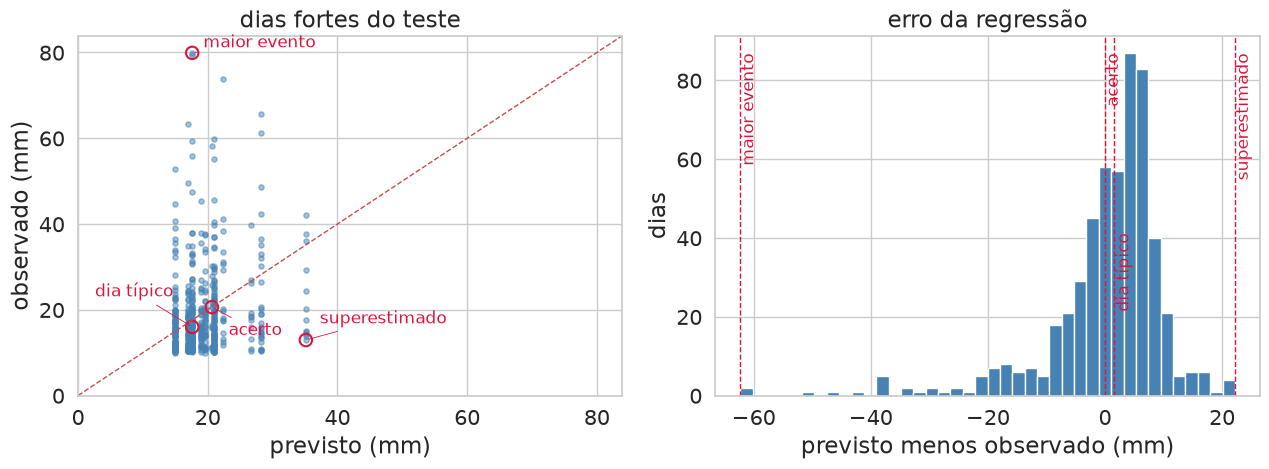

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lim = [0, obs.tp_mm.max() * 1.05]
axes[0].scatter(obs.pred_reg, obs.tp_mm, s=14, alpha=.5, color="steelblue")
axes[0].plot(lim, lim, "r--", lw=1)
desloc = {"acerto": (12, -20), "dia típico": (-70, 22), "superestimado": (10, 12)}
for papel, r in escolhidos.iterrows():
    axes[0].annotate(papel, (r.pred_reg, r.tp_mm), fontsize=12, color="crimson",
                     xytext=desloc.get(papel, (8, 4)), textcoords="offset points",
                     arrowprops={"arrowstyle": "-", "color": "crimson", "lw": .6})
    axes[0].scatter(r.pred_reg, r.tp_mm, s=80, facecolors="none", edgecolors="crimson", lw=1.5)
axes[0].set(title="dias fortes do teste", xlabel="previsto (mm)", ylabel="observado (mm)",
            xlim=lim, ylim=lim)

axes[1].hist(obs.erro_reg, bins=40, color="steelblue")
altura = {"dia típico": .45}                     # afasta do rótulo do "acerto"
for papel, r in escolhidos.iterrows():
    axes[1].axvline(r.erro_reg, color="crimson", ls="--", lw=1)
    axes[1].text(r.erro_reg, axes[1].get_ylim()[1] * altura.get(papel, .95), f" {papel}", rotation=90,
                 va="top", fontsize=12, color="crimson")
axes[1].set(title="erro da regressão", xlabel="previsto menos observado (mm)", ylabel="dias")

plt.tight_layout()
salvar("observacoes")
plt.show()

salvo: arvore_caminhos.png


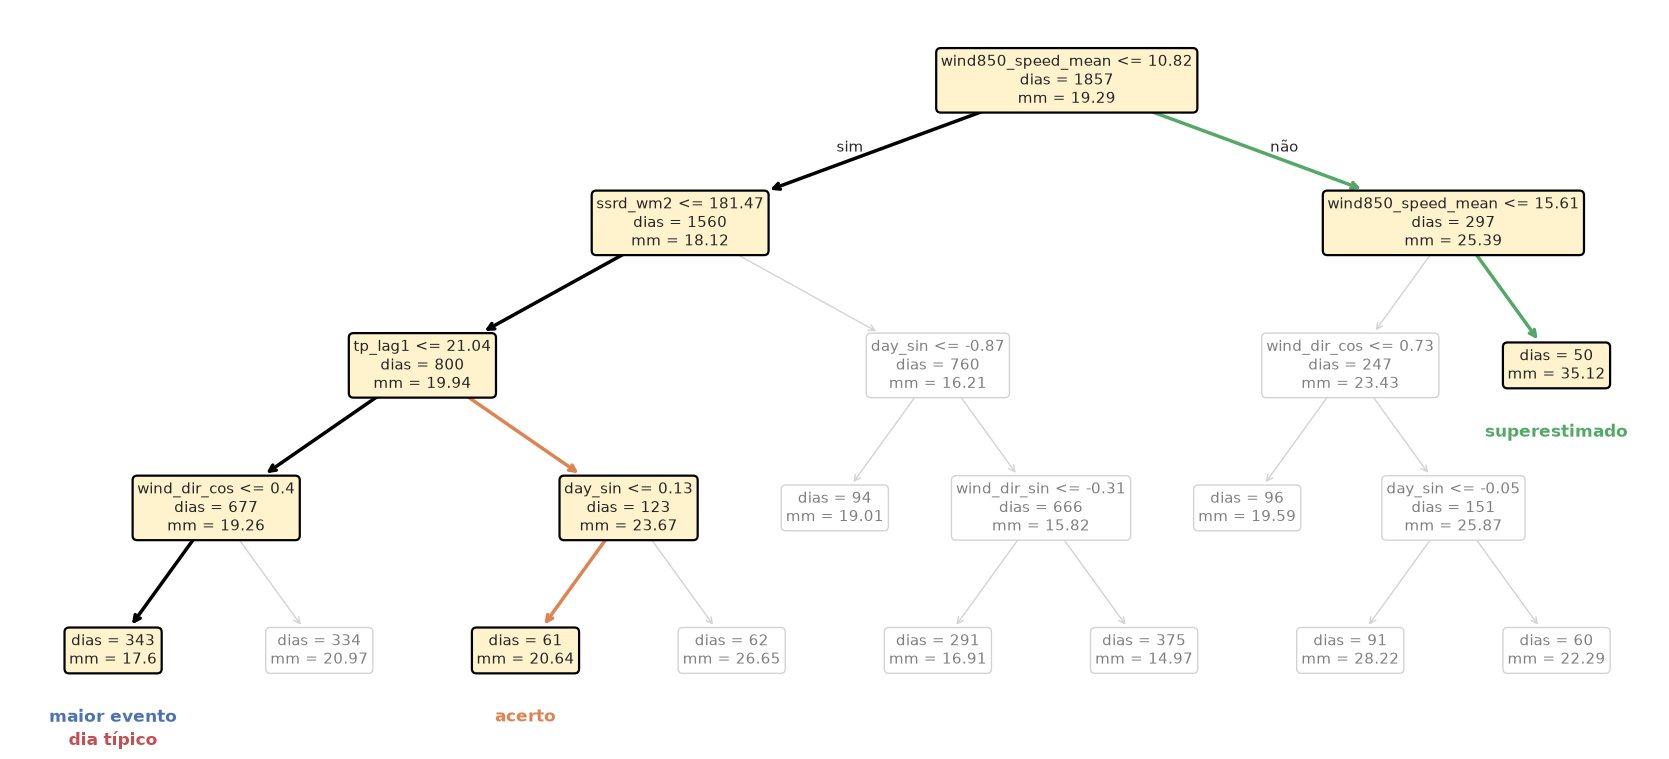

{'maior evento': 'folha 4, 17.60 mm', 'acerto': 'folha 7, 20.64 mm', 'superestimado': 'folha 20, 35.12 mm', 'dia típico': 'folha 4, 17.60 mm'}


In [9]:
from sklearn.tree import plot_tree

# a árvore inteira, com o caminho de cada dia escolhido destacado
cores = dict(zip(escolhidos.index, sns.color_palette("deep", len(escolhidos))))
caminho = arvore.decision_path(escolhidos[F]).toarray().astype(bool)   # dia × nó
folha = arvore.apply(escolhidos[F])

fig, ax = plt.subplots(figsize=(17, 8))
todas = plot_tree(arvore, feature_names=F, impurity=False, filled=False, rounded=True,
                  precision=2, fontsize=11, ax=ax)
# além dos nós, plot_tree escreve "True"/"False" nos ramos da raiz; sem eles, a ordem é a dos ids
anots = [a for a in todas if a.get_text().strip() not in ("True", "False")]
for a in todas:                                    # rótulos em português
    t = a.get_text().replace("samples", "dias").replace("value", "mm")
    a.set_text(t.replace("True", "sim").replace("False", "não"))
assert len(anots) == arvore.tree_.node_count
for no, a in enumerate(anots):
    dias_no = [papel for k, papel in enumerate(escolhidos.index) if caminho[k, no]]
    if dias_no:
        a.set_bbox(dict(boxstyle="round", facecolor="#fff3cd", edgecolor="black", linewidth=1.6))
        if a.arrow_patch is not None:
            cor = cores[dias_no[0]] if len(dias_no) == 1 else "black"
            a.arrow_patch.set(color=cor, linewidth=2.5)
    else:
        a.set_bbox(dict(boxstyle="round", facecolor="white", edgecolor="lightgray"))
        a.set_color("gray")
        if a.arrow_patch is not None:
            a.arrow_patch.set(color="lightgray")
# o nome dos dias embaixo da folha em que cada um termina
for no in np.unique(folha):
    x, y = anots[no].get_position()
    nomes = [papel for k, papel in enumerate(escolhidos.index) if folha[k] == no]
    for j, papel in enumerate(nomes):
        ax.annotate(papel, (x, y), xytext=(0, -42 - 16 * j), textcoords="offset points",
                    ha="center", va="top", fontsize=12, color=cores[papel], fontweight="bold")
plt.tight_layout()
salvar("arvore_caminhos")
plt.show()

print({papel: f"folha {no}, {arvore.tree_.value[no][0][0]:.2f} mm" for papel, no in zip(escolhidos.index, folha)})

## 3. CP Plot e ICE

**CP** (*ceteris paribus*): para um dia, varia uma feature e mantém as outras fixas. **ICE**: o CP de todos os dias fortes do teste; a média das curvas é o PDP.

In [10]:
import warnings
import dalex as dx
from sklearn.inspection import partial_dependence

warnings.filterwarnings("ignore", message="Parameter `variable_splits`")

# importância por impureza; features com 0 não entram em split nenhum
imp = pd.Series(arvore.feature_importances_, index=F).sort_values(ascending=False)
print(imp.round(3).to_string())

FEATS_CP = imp.index[:4].tolist()                    # as 4 mais usadas pela árvore
print("\nfeatures dos gráficos:", FEATS_CP)

# grade: 101 quantis de cada feature nos dias fortes do teste
GRADE_CP = {f: np.unique(np.quantile(teste[f], np.linspace(0, 1, 101))) for f in F}

wind850_speed_mean    0.517
ssrd_wm2              0.185
wind_dir_cos          0.124
day_sin               0.090
tp_lag1               0.060
wind_dir_sin          0.024
t2m                   0.000
d2m                   0.000
dpd                   0.000
wind_const            0.000
wind_speed            0.000
day_cos               0.000

features dos gráficos: ['wind850_speed_mean', 'ssrd_wm2', 'wind_dir_cos', 'day_sin']


In [11]:
exp_reg = dx.Explainer(arvore, teste[F], teste.tp_mm, label="regressão", verbose=False)
cp = exp_reg.predict_profile(escolhidos[F], variable_splits=GRADE_CP, verbose=False).result

# amplitude do CP: quanto a previsão do dia pode mudar mexendo só nesta feature
amp_cp = cp.groupby(["_vname_", "_ids_"])._yhat_.agg(lambda s: s.max() - s.min()).unstack()[escolhidos.index]
amp_cp.index.name = None
print(amp_cp.round(2).to_string())

_ids_               maior evento  acerto  superestimado  dia típico
d2m                         0.00    0.00           0.00        0.00
day_cos                     0.00    0.00           0.00        0.00
day_sin                     0.00    6.01           0.00        0.00
dpd                         0.00    0.00           0.00        0.00
ssrd_wm2                    2.64    1.63           0.00        2.64
t2m                         0.00    0.00           0.00        0.00
tp_lag1                     3.04    0.33           0.00        9.05
wind850_speed_mean         17.52   14.48          14.16       17.52
wind_const                  0.00    0.00           0.00        0.00
wind_dir_cos                3.36    0.00           0.00        3.36
wind_dir_sin                0.00    0.00           0.00        0.00
wind_speed                  0.00    0.00           0.00        0.00


In [12]:
# o CP muda uma variável e congela as outras, então visita combinações que não existem.
# Quanto da grade é impossível para o dia superestimado?
d = escolhidos.loc["superestimado"]
mes = d.date.month
max_mes = df[df.date.dt.month == mes].ssrd_wm2.max()
cos_ok = np.sqrt(1 - d.wind_dir_sin ** 2)
print(f"orvalho acima da temperatura do dia ({d.t2m:.1f} °C): "
      f"{100 * (GRADE_CP['d2m'] > d.t2m).mean():.0f}% da grade de d2m")
print(f"cosseno fora do círculo (seno fixo em {d.wind_dir_sin:.2f}, cosseno possível ±{cos_ok:.2f}): "
      f"{100 * (np.abs(np.abs(GRADE_CP['wind_dir_cos']) - cos_ok) > 0.05).mean():.0f}% da grade")
print(f"radiação: grade vai até {GRADE_CP['ssrd_wm2'].max():.0f} W/m², máximo já registrado no mês {mes}: {max_mes:.0f} W/m²")

orvalho acima da temperatura do dia (17.5 °C): 42% da grade de d2m
cosseno fora do círculo (seno fixo em -0.38, cosseno possível ±0.92): 84% da grade
radiação: grade vai até 354 W/m², máximo já registrado no mês 6: 189 W/m²


salvo: cp_plot.png


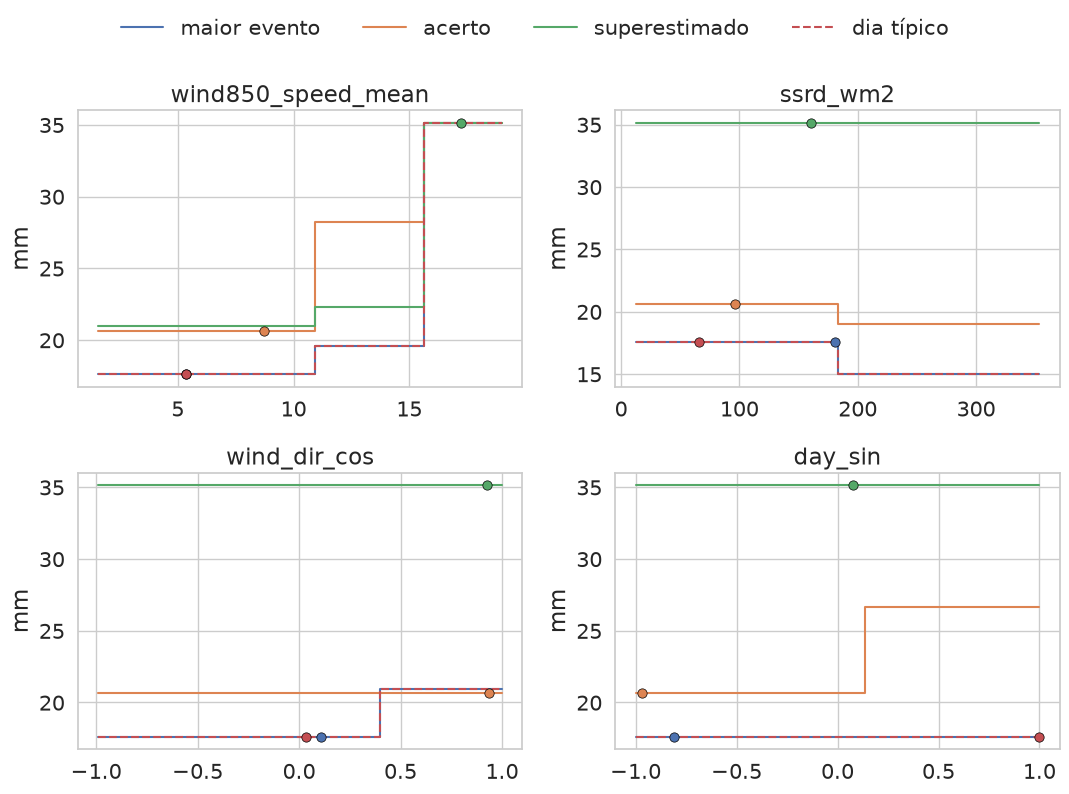

In [13]:
cores = dict(zip(escolhidos.index, sns.color_palette("deep", len(escolhidos))))
# maior evento e dia típico caem na mesma folha: tracejado para um não esconder o outro
traco = {"dia típico": "--"}

fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
for ax, f in zip(axes.flat, FEATS_CP):
    for papel in escolhidos.index:
        g = cp[(cp._vname_ == f) & (cp._ids_ == papel)]
        ax.step(g[f], g._yhat_, where="post", color=cores[papel], lw=1.5, ls=traco.get(papel, "-"), label=papel)
        ax.scatter(escolhidos.loc[papel, f], escolhidos.loc[papel, "pred_reg"],
                   color=cores[papel], s=45, zorder=5, edgecolor="black", lw=.5)
    ax.set(title=f, xlabel="", ylabel="mm")
plt.tight_layout()
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="lower center",
           bbox_to_anchor=(.5, 1.0), ncol=len(escolhidos), frameon=False)
salvar("cp_plot")
plt.show()

In [14]:
ice = {}
for f in F:
    pdr = partial_dependence(arvore, teste[F], [f], kind="both", custom_values={f: GRADE_CP[f]})
    ice[f] = (pdr["grid_values"][0], pdr["individual"][0], pdr["average"][0])

# PDP mede o efeito médio; amplitude média das curvas individuais mede o efeito dia a dia.
# Muitas curvas planas com PDP inclinado = a feature só importa em alguns ramos (interação).
het = pd.DataFrame([
    {"feature": f, "amp_PDP": avg.max() - avg.min(),
     "amp_ICE_media": (ind.max(axis=1) - ind.min(axis=1)).mean(),
     "pct_curvas_planas": 100 * ((ind.max(axis=1) - ind.min(axis=1)) < 1e-9).mean()}
    for f, (_, ind, avg) in ice.items()]).set_index("feature")
print(het.round(2).to_string())

                    amp_PDP  amp_ICE_media  pct_curvas_planas
feature                                                      
ssrd_wm2               2.87           3.09              17.29
t2m                    0.00           0.00             100.00
d2m                    0.00           0.00             100.00
dpd                    0.00           0.00             100.00
wind_speed             0.00           0.00             100.00
wind_const             0.00           0.00             100.00
wind_dir_sin           0.62           0.62              68.03
wind_dir_cos           2.17           2.17              46.28
day_sin                1.77           2.04              47.96
day_cos                0.00           0.00             100.00
tp_lag1                1.84           1.91              56.88
wind850_speed_mean    16.79          17.10               0.00


salvo: ice.png


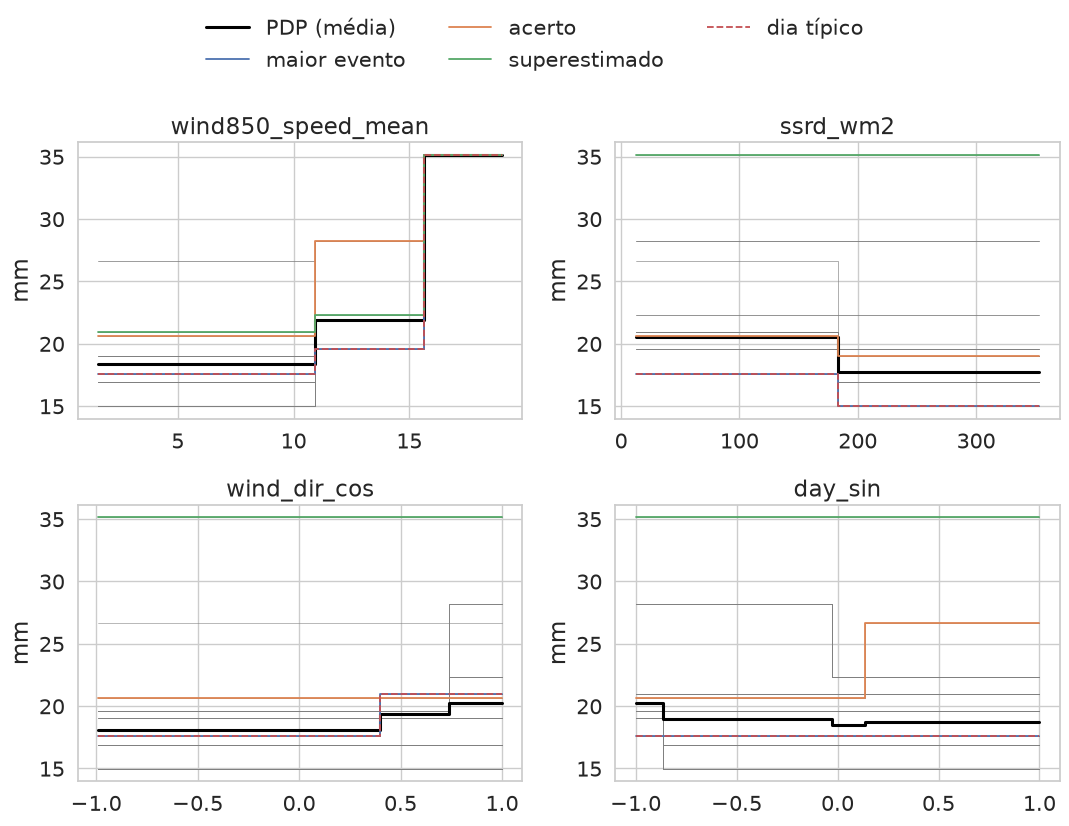

In [15]:
rng = np.random.default_rng(42)

fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
for ax, f in zip(axes.flat, FEATS_CP):
    grade, ind, avg = ice[f]
    for k in rng.choice(len(ind), size=min(300, len(ind)), replace=False):
        ax.step(grade, ind[k], where="post", color="gray", lw=.4, alpha=.25)
    ax.step(grade, avg, where="post", color="black", lw=2.2, label="PDP (média)")
    for papel in escolhidos.index:
        g = cp[(cp._vname_ == f) & (cp._ids_ == papel)]
        ax.step(g[f], g._yhat_, where="post", color=cores[papel], lw=1.3, ls=traco.get(papel, "-"), label=papel)
    ax.set(title=f, xlabel="", ylabel="mm")
plt.tight_layout()
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="lower center",
           bbox_to_anchor=(.5, 1.0), ncol=3, frameon=False)
salvar("ice")
plt.show()

## 4. LIME

Sorteia vizinhos a partir do treino, pergunta ao modelo a previsão de cada um e ajusta uma regressão linear ponderada pela distância. Os pesos dessa reta são a explicação.

In [16]:
from lime.lime_tabular import LimeTabularExplainer

# parâmetros padrão: quartis do treino, 5.000 vizinhos, núcleo de largura 0,75·√12, Ridge
lime_exp = LimeTabularExplainer(dev[F].values, feature_names=F, mode="regression", random_state=42)
prever = lambda X: arvore.predict(pd.DataFrame(X, columns=F))

def explicar_lime(papel, seed=42):
    lime_exp.random_state = np.random.RandomState(seed)
    e = lime_exp.explain_instance(escolhidos.loc[papel, F].values.astype(float), prever,
                                  num_features=len(F), num_samples=5000)
    return dict(e.as_list()), e.score, e.local_pred[0]

lime_res, lime_fid = {}, []
for papel in escolhidos.index:
    pesos, r2, local = explicar_lime(papel)
    lime_res[papel] = pesos
    lime_fid.append({"papel": papel, "previsão_modelo": escolhidos.loc[papel, "pred_reg"],
                     "previsão_LIME": local, "R2_local": r2})
print(pd.DataFrame(lime_fid).set_index("papel").round(3).to_string())

               previsão_modelo  previsão_LIME  R2_local
papel                                                  
maior evento            17.603         15.694     0.098
acerto                  20.641         22.298     0.113
superestimado           35.123         24.746     0.267
dia típico              17.603         18.293     0.103


salvo: lime.png


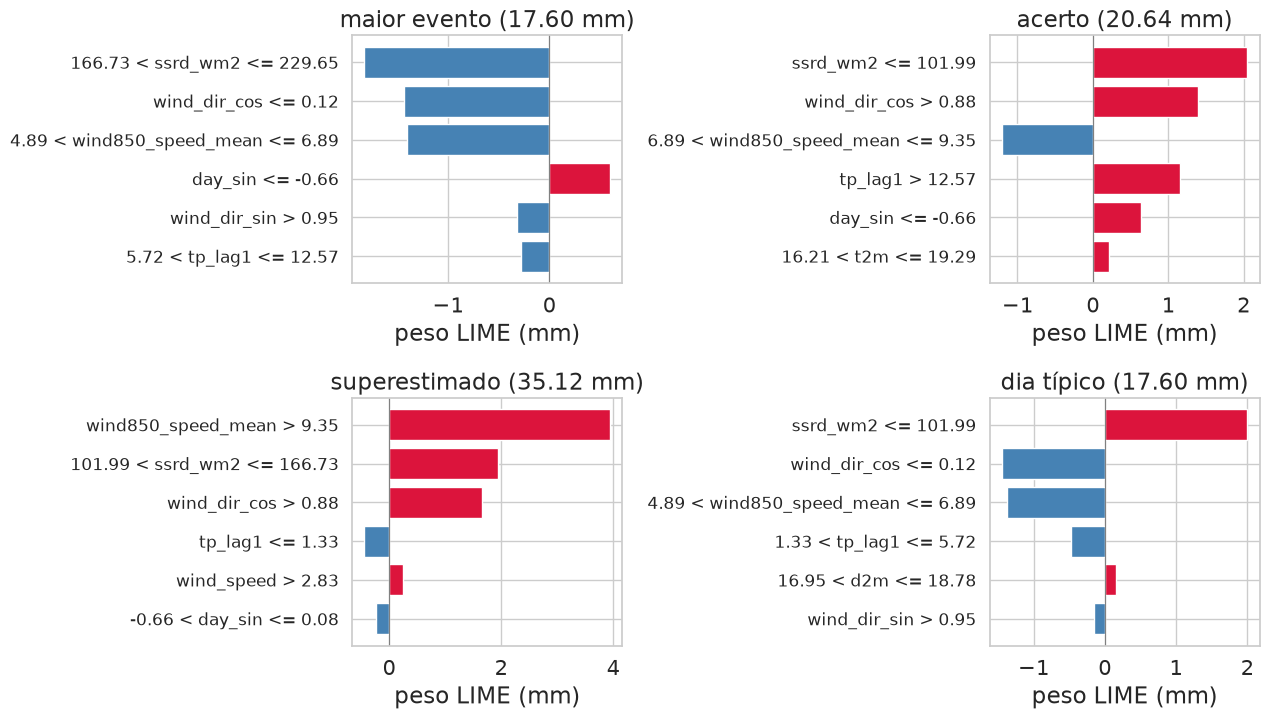

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))
for ax, papel in zip(axes.flat, escolhidos.index):
    w = pd.Series(lime_res[papel]).sort_values(key=abs).tail(6)
    ax.barh(w.index, w.values, color=["crimson" if v > 0 else "steelblue" for v in w.values])
    ax.axvline(0, color="gray", lw=.8)
    ax.tick_params(axis="y", labelsize=12)
    ax.set(title=f"{papel} ({escolhidos.loc[papel, 'pred_reg']:.2f} mm)", xlabel="peso LIME (mm)")
plt.tight_layout()
salvar("lime")
plt.show()

In [18]:
# estabilidade: o LIME sorteia vizinhos, então sementes diferentes dão explicações diferentes
def feat_de(chave):
    return next(f for f in sorted(F, key=len, reverse=True) if f in chave)

estab = []
for papel in escolhidos.index:
    tops = []
    for seed in range(10):
        pesos, _, _ = explicar_lime(papel, seed=seed)
        por_feat = pd.Series({feat_de(k): abs(v) for k, v in pesos.items()})
        tops.append(tuple(sorted(por_feat.nlargest(3).index)))
    mais_comum = pd.Series(tops).value_counts()
    estab.append({"papel": papel, "top3_mais_comum": mais_comum.index[0],
                  "pct_sementes": 10 * mais_comum.iloc[0]})
print(pd.DataFrame(estab).set_index("papel").to_string())
print("\npeso do LIME em d2m, que a árvore não usa:",
      {p: [round(v, 3) for k, v in lime_res[p].items() if "d2m" in k] for p in escolhidos.index})

                                            top3_mais_comum  pct_sementes
papel                                                                    
maior evento   (ssrd_wm2, wind850_speed_mean, wind_dir_cos)           100
acerto                    (ssrd_wm2, tp_lag1, wind_dir_cos)            40
superestimado  (ssrd_wm2, wind850_speed_mean, wind_dir_cos)           100
dia típico     (ssrd_wm2, wind850_speed_mean, wind_dir_cos)           100

peso do LIME em d2m, que a árvore não usa: {'maior evento': [0.039], 'acerto': [-0.206], 'superestimado': [-0.043], 'dia típico': [0.16]}


## 5. SHAP

Divide a diferença entre a previsão do dia e a previsão média entre as features (valores de Shapley). O TreeSHAP é exato para árvores.

In [19]:
warnings.filterwarnings("ignore", message="IProgress not found")
import shap

tree_exp = shap.TreeExplainer(arvore)
shap_res = pd.DataFrame(tree_exp.shap_values(escolhidos[F]), index=escolhidos.index, columns=F)
base = float(np.ravel(tree_exp.expected_value)[0])

# aditividade: base + soma dos SHAP = previsão do modelo
assert np.allclose(base + shap_res.sum(axis=1), escolhidos.pred_reg)
print(f"valor base {base:.3f} mm | base + soma = previsão em todos os dias\n")
print(shap_res.T.round(3).to_string())

valor base 19.287 mm | base + soma = previsão em todos os dias

papel               maior evento  acerto  superestimado  dia típico
ssrd_wm2                   1.395   1.416          0.765       1.465
t2m                        0.000   0.000          0.000       0.000
d2m                        0.000   0.000          0.000       0.000
dpd                        0.000   0.000          0.000       0.000
wind_speed                 0.000   0.000          0.000       0.000
wind_const                 0.000   0.000          0.000       0.000
wind_dir_sin              -0.170   0.137          0.136      -0.170
wind_dir_cos              -1.375   0.621          0.568      -1.295
day_sin                   -0.171  -0.698         -0.308      -0.051
day_cos                    0.000   0.000          0.000       0.000
tp_lag1                   -0.392   1.024         -0.115      -0.761
wind850_speed_mean        -0.970  -1.146         14.790      -0.872


salvo: shap.png


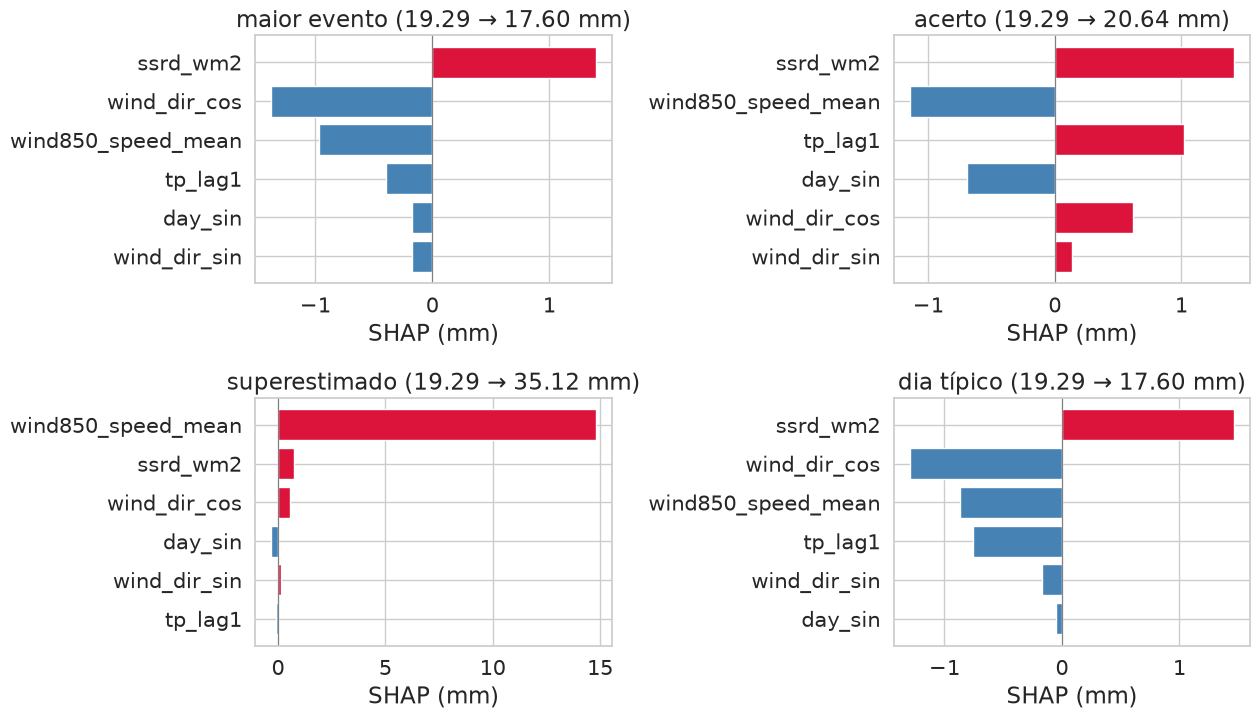

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))
for ax, papel in zip(axes.flat, escolhidos.index):
    s = shap_res.loc[papel].sort_values(key=abs).tail(6)
    ax.barh(s.index, s.values, color=["crimson" if v > 0 else "steelblue" for v in s.values])
    ax.axvline(0, color="gray", lw=.8)
    ax.set(title=f"{papel} ({base:.2f} → {escolhidos.loc[papel, 'pred_reg']:.2f} mm)", xlabel="SHAP (mm)")
plt.tight_layout()
salvar("shap")
plt.show()

## 6. Método adicional: contrafactuais com DiCE

Que mudança mínima nas variáveis levaria a previsão da árvore para outra faixa (Mothilal et al., 2020)? Busca aleatória, com o dia do ano fixo. Para os dias previstos abaixo de 30 mm, a faixa-alvo é de 30 a 40 mm, a folha mais alta da árvore. Para o superestimado, é de 10 a 18 mm, perto do que choveu. Cada contrafactual é conferido no modelo, e os fisicamente impossíveis são marcados: orvalho acima da temperatura, `dpd` diferente de `t2m − d2m`, seno e cosseno fora do círculo, ou radiação acima do máximo já registrado no mês do dia.

In [21]:
import dice_ml

dice_dados = dice_ml.Data(dataframe=dev[F + ["tp_mm"]].astype(float), continuous_features=F,
                          outcome_name="tp_mm")
dice_exp = dice_ml.Dice(dice_dados, dice_ml.Model(model=arvore, backend="sklearn", model_type="regressor"),
                        method="random")
VARIA = [f for f in F if f not in ("day_sin", "day_cos")]          # a data não muda
MAX_MES = df.groupby(df.date.dt.month).ssrd_wm2.max()

def impossivel(cf, mes):
    return bool(cf.d2m > cf.t2m or abs(cf.dpd - (cf.t2m - cf.d2m)) > 0.5
                or abs(cf.wind_dir_sin ** 2 + cf.wind_dir_cos ** 2 - 1) > 0.1
                or cf.ssrd_wm2 > MAX_MES[mes])

cfs = []
for papel in escolhidos.index:
    q = escolhidos.loc[[papel], F].astype(float)
    p0 = escolhidos.loc[papel, "pred_reg"]
    faixa = [10.0, 18.0] if p0 >= 30 else [30.0, 40.0]
    r = dice_exp.generate_counterfactuals(q, total_CFs=20, desired_range=faixa, features_to_vary=VARIA,
                                          random_seed=42, verbose=False)
    final = r.cf_examples_list[0].final_cfs_df
    if final is None:
        continue
    for _, cf in final[F].astype(float).iterrows():
        p1 = arvore.predict(cf.to_frame().T)[0]
        if not faixa[0] <= p1 <= faixa[1]:
            continue                                     # não chegou à faixa de verdade
        mud = {f: (round(q.iloc[0][f], 2), round(cf[f], 2)) for f in F if abs(cf[f] - q.iloc[0][f]) > 1e-6}
        cfs.append({"papel": papel, "faixa": f"{faixa[0]:g} a {faixa[1]:g} mm", "antes": round(p0, 2),
                    "depois": round(p1, 2), "n_mudanças": len(mud),
                    "impossível": impossivel(cf, escolhidos.loc[papel, "date"].month),
                    "mudanças (de, para)": mud})

cfs = pd.DataFrame(cfs).sort_values(["papel", "impossível", "n_mudanças"])
with pd.option_context("display.max_colwidth", 250):
    print(cfs.groupby("papel", sort=False).head(4).to_string(index=False))
print()
print(cfs.groupby("papel", sort=False).agg(contrafactuais=("n_mudanças", "size"),
                                           impossíveis=("impossível", "sum"),
                                           mínimo_de_mudanças=("n_mudanças", "min")).to_string())

100%|██████████| 1/1 [00:00<00:00, 10.00it/s]

        papel      faixa  antes  depois  n_mudanças  impossível                                                   mudanças (de, para)
       acerto 30 a 40 mm  20.64   35.12           1       False                                  {'wind850_speed_mean': (8.72, 15.9)}
       acerto 30 a 40 mm  20.64   35.12           1       False                                 {'wind850_speed_mean': (8.72, 19.11)}
       acerto 30 a 40 mm  20.64   35.12           1       False                                 {'wind850_speed_mean': (8.72, 19.67)}
       acerto 30 a 40 mm  20.64   35.12           1       False                                 {'wind850_speed_mean': (8.72, 17.56)}
   dia típico 30 a 40 mm  17.60   35.12           1       False                                  {'wind850_speed_mean': (5.36, 15.9)}
   dia típico 30 a 40 mm  17.60   35.12           1       False                                 {'wind850_speed_mean': (5.36, 19.11)}
   dia típico 30 a 40 mm  17.60   35.12           1       Fals

## Comparação entre os métodos

In [22]:
from scipy.stats import spearmanr

comp = []
for papel in escolhidos.index:
    lime_abs = pd.Series({feat_de(k): abs(v) for k, v in lime_res[papel].items()}).reindex(F)
    shap_abs = shap_res.loc[papel].abs()
    cp_amp   = amp_cp[papel].reindex(F)
    comp.append({
        "papel": papel,
        "top3_CP":   ", ".join(cp_amp[cp_amp > 1e-9].nlargest(3).index),   # só as que mexem
        "top3_LIME": ", ".join(lime_abs.nlargest(3).index),
        "top3_SHAP": ", ".join(shap_abs[shap_abs > 1e-9].nlargest(3).index),
        "spearman_LIME_SHAP": spearmanr(lime_abs, shap_abs).statistic,
        "SHAP_zero": int((shap_abs < 1e-9).sum()),
    })
comp = pd.DataFrame(comp).set_index("papel")
print(comp.round(2).to_string())

                                                 top3_CP                                   top3_LIME                                   top3_SHAP  spearman_LIME_SHAP  SHAP_zero
papel                                                                                                                                                                          
maior evento   wind850_speed_mean, wind_dir_cos, tp_lag1  ssrd_wm2, wind_dir_cos, wind850_speed_mean  ssrd_wm2, wind_dir_cos, wind850_speed_mean                0.91          6
acerto             wind850_speed_mean, day_sin, ssrd_wm2  ssrd_wm2, wind_dir_cos, wind850_speed_mean       ssrd_wm2, wind850_speed_mean, tp_lag1                0.79          6
superestimado                         wind850_speed_mean  wind850_speed_mean, ssrd_wm2, wind_dir_cos  wind850_speed_mean, ssrd_wm2, wind_dir_cos                0.74          6
dia típico     wind850_speed_mean, tp_lag1, wind_dir_cos  ssrd_wm2, wind_dir_cos, wind850_speed_mean  ssrd_wm2, wind_dir